# Análisis exploratorio de BD Dengue

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Cargar BD
df = pd.read_excel(r"C:\Users\usuario1\OneDrive - Universidad de Antioquia\UNIVERSIDAD DE ANTIOQUIA\Proyecto SAT Dengue\Bases de datos\Secretaria de salud\BD_DENGUE_2021-2025_PROCE_CAUCASIA.xlsx")

In [3]:
# Revisar los primeros datos
df.head()

,fec_not,semana,año,area_,localidad_,cen_pobla_,vereda_,bar_ver_,dir_res_,ndep_proce,nmun_proce,nmun_resi
0,2021-02-16,3,2021,2,NaN,CAUCASIA,NaN,CAUCASIA,CR 39 E 48 C SUR 36,ANTIOQUIA,CAUCASIA,ENVIGADO
1,2021-02-19,6,2021,2,NaN,CAUCASIA,NaN,CAUCASIA,CL 29 A 42-99,ANTIOQUIA,CAUCASIA,BOGOTA
2,2021-02-28,7,2021,1,VILLA GRANDA,NaN,NaN,VILLA GRANDA,VILLA GRANDA,ANTIOQUIA,CAUCASIA,CAUCASIA
3,2021-03-12,9,2021,3,NaN,NaN,CUTURÚ,CUTURÚ,CUTURU,ANTIOQUIA,CAUCASIA,CAUCASIA
4,2021-04-05,13,2021,1,LA YE,NaN,NaN,LA YE,LA Y CARRERA 22 33 19,ANTIOQUIA,CAUCASIA,CAUCASIA


In [4]:
# Ver estructura de la base de datos
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6104 entries, 0 to 6103
Data columns (total 12 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   fec_not     6104 non-null   datetime64[ns]
 1   semana      6104 non-null   int64         
 2   año         6104 non-null   int64         
 3   area_       6104 non-null   int64         
 4   localidad_  5131 non-null   object        
 5   cen_pobla_  59 non-null     object        
 6   vereda_     914 non-null    object        
 7   bar_ver_    6104 non-null   object        
 8   dir_res_    6104 non-null   object        
 9   ndep_proce  6104 non-null   object        
 10  nmun_proce  6104 non-null   object        
 11  nmun_resi   6104 non-null   object        
dtypes: datetime64[ns](1), int64(3), object(8)
memory usage: 572.4+ KB


In [6]:
# Revisar valores nulos
df.isnull().sum()

fec_not          0
semana           0
año              0
area_            0
localidad_     973
cen_pobla_    6045
vereda_       5190
bar_ver_         0
dir_res_         0
ndep_proce       0
nmun_proce       0
nmun_resi        0
dtype: int64

In [7]:
# Convertir la columna 'fec_not' a formato de fecha
df['fec_not'] = pd.to_datetime(df['fec_not'])

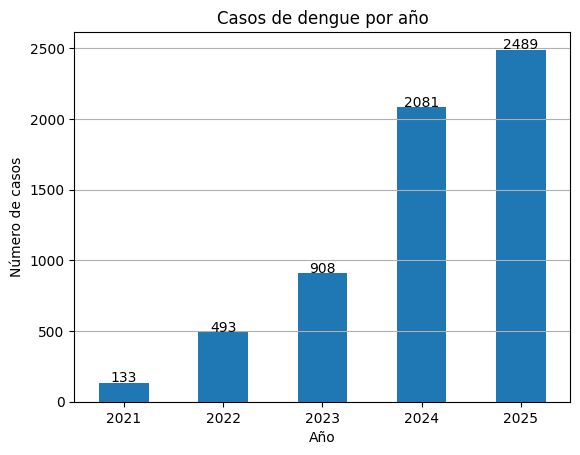

In [40]:
# Casos por año
casos_año = df['año'].value_counts().sort_index()

plt.figure()

ax = casos_año.plot(kind='bar')

plt.title("Casos de dengue por año")
plt.xlabel("Año")
plt.ylabel("Número de casos")
plt.xticks(rotation=0)
plt.grid(axis='y')

# Mostrar valores sobre cada barra
for i, v in enumerate(casos_año):
    ax.text(i, v + 5, str(v), ha='center')

plt.show()

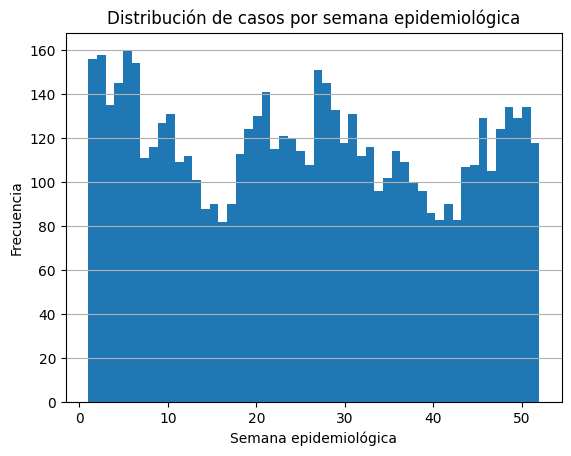

In [11]:
# Casos por semana epidemiológica
plt.figure()

plt.hist(df['semana'], bins=52)

plt.title("Distribución de casos por semana epidemiológica")
plt.xlabel("Semana epidemiológica")
plt.ylabel("Frecuencia")
plt.grid(axis='y')

plt.show()

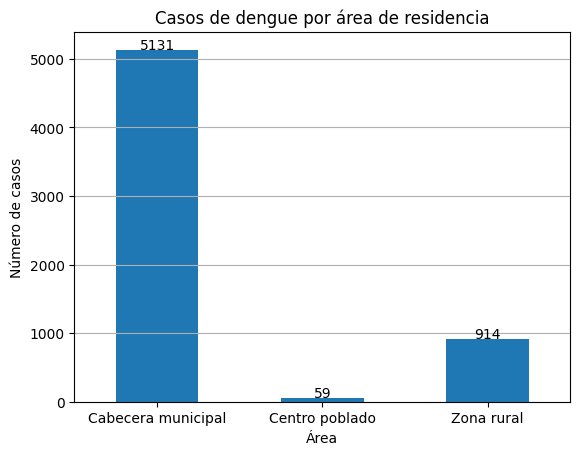

In [39]:
# Analizar casos por área
casos_area = df['area_'].value_counts().sort_index()

# Reemplazar códigos por nombres
casos_area.index = ['Cabecera municipal', 'Centro poblado', 'Zona rural']

plt.figure()

ax = casos_area.plot(kind='bar')

plt.title("Casos de dengue por área de residencia")
plt.xlabel("Área")
plt.ylabel("Número de casos")
plt.xticks(rotation=0)
plt.grid(axis='y')

# Mostrar número de casos sobre cada barra
for i, v in enumerate(casos_area):
    ax.text(i, v + 5, str(v), ha='center')

plt.show()

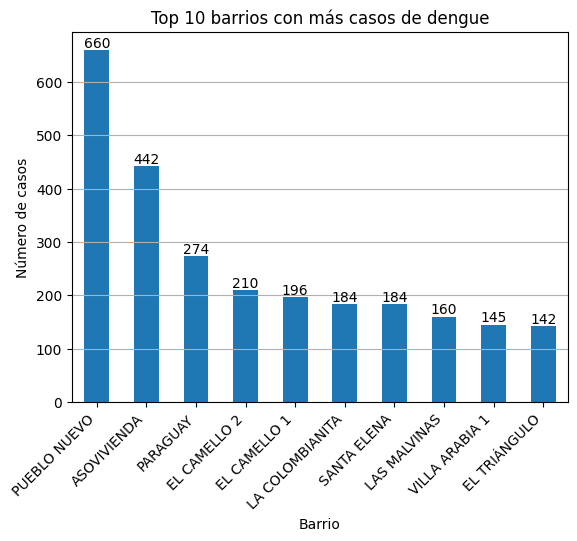

In [52]:
barrios = df['bar_ver_'].value_counts().head(10)

plt.figure()

barrios.plot(kind='bar')

plt.title("Top 10 barrios con más casos de dengue")
plt.xlabel("Barrio")
plt.ylabel("Número de casos")

plt.xticks(rotation=45, ha='right')
plt.grid(axis='y')

# Mostrar número de casos sobre cada barra
for i, v in enumerate(barrios):
    plt.text(i, v + 5, str(v), ha='center')

plt.show()

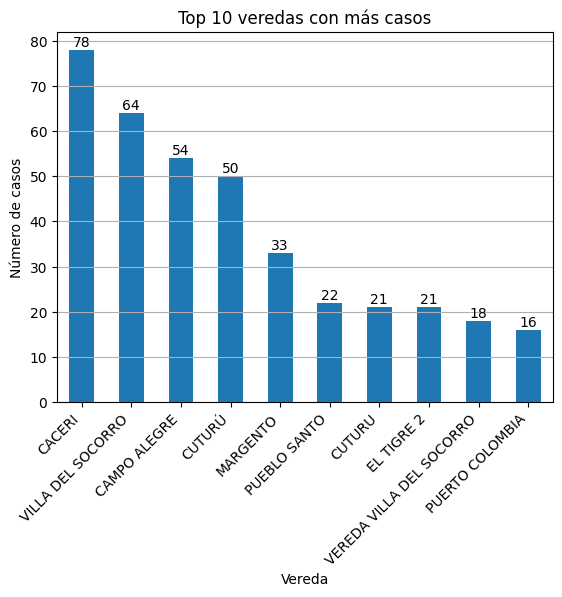

In [60]:
veredas = df['vereda_'].value_counts().head(10)

plt.figure()

veredas.plot(kind='bar')

plt.title("Top 10 veredas con más casos")
plt.xlabel("Vereda")
plt.ylabel("Número de casos")

plt.xticks(rotation=45, ha='right')
plt.grid(axis='y')

# Mostrar número de casos sobre cada barra
for i, v in enumerate(veredas):
    plt.text(i, v + 0.8, str(v), ha='center')

plt.show()

In [28]:
# Casos por año y semana epidemiológica
casos_semana = df.groupby(['año','semana']).size().reset_index(name='casos')

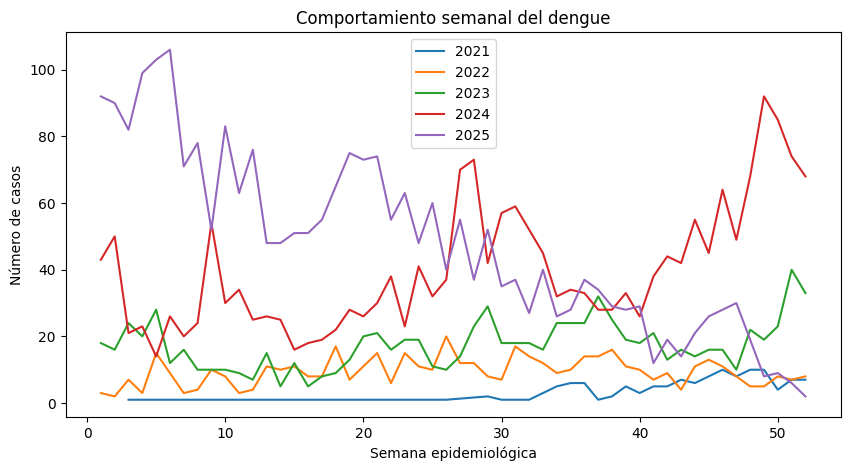

In [29]:
# Graficar comportamiento semanal del dengue por año
plt.figure(figsize=(10,5))

for año in casos_semana['año'].unique():

    subset = casos_semana[casos_semana['año'] == año]

    plt.plot(subset['semana'], subset['casos'], label=año)

plt.legend()

plt.xlabel("Semana epidemiológica")
plt.ylabel("Número de casos")

plt.title("Comportamiento semanal del dengue")

plt.show()

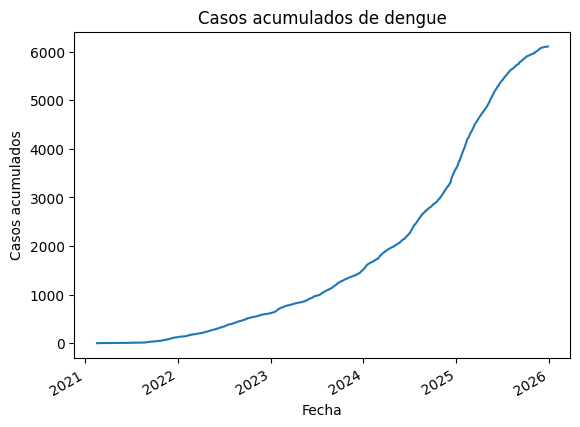

In [63]:
# Casos acumulados por fecha de notificación
casos_fecha = df.groupby('fec_not').size()

casos_acumulados = casos_fecha.cumsum()

plt.figure()

casos_acumulados.plot()

plt.title("Casos acumulados de dengue")

plt.xlabel("Fecha")

plt.ylabel("Casos acumulados")

plt.show()

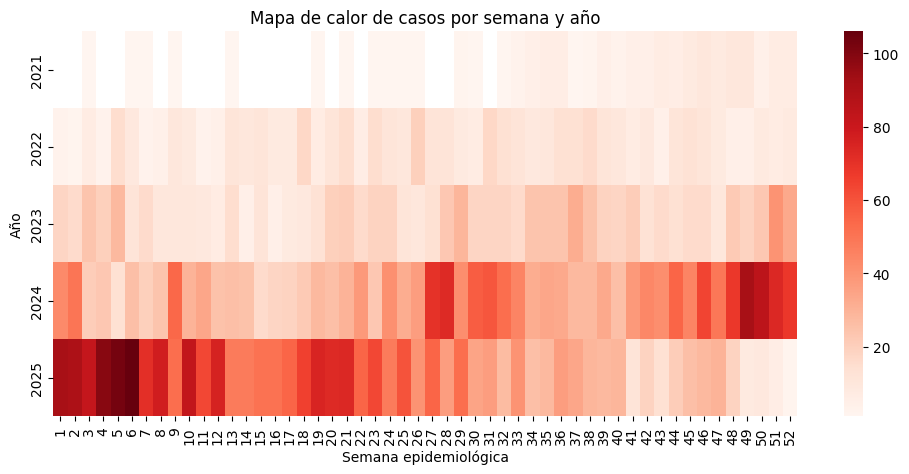

In [31]:
# Heatmap de semanas por año
tabla = df.groupby(['año','semana']).size().unstack()

plt.figure(figsize=(12,5))

sns.heatmap(tabla, cmap="Reds")

plt.title("Mapa de calor de casos por semana y año")

plt.xlabel("Semana epidemiológica")

plt.ylabel("Año")

plt.show()